In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.linear_model import LinearRegression



# 1 - Data exploration

## 1.1 - inspect data types

In [2]:
df = pd.read_csv("2025_DS2_HW1_data_train.csv")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32647 entries, 0 to 32646
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            32647 non-null  str    
 1   no_of_adults                          28231 non-null  float64
 2   no_of_children                        5043 non-null   float64
 3   no_of_weekend_nights                  7729 non-null   float64
 4   no_of_week_nights                     24287 non-null  float64
 5   type_of_meal_plan                     16544 non-null  str    
 6   required_car_parking_space            17863 non-null  float64
 7   room_type_reserved                    11360 non-null  str    
 8   lead_time                             6935 non-null   float64
 9   arrival_year                          29654 non-null  float64
 10  arrival_month                         31740 non-null  float64
 11  arrival_date              

We see that we have 15 variables with "float64" data types and 4 with "object" data types.

## 1.2 - missing values

In [3]:
missing_counts = df.isnull().sum()
info_summary = pd.DataFrame({
    'Percentage Missing': (df.isnull().sum() / len(df)) * 100
})

print(missing_counts)
print(info_summary)

Booking_ID                                  0
no_of_adults                             4416
no_of_children                          27604
no_of_weekend_nights                    24918
no_of_week_nights                        8360
type_of_meal_plan                       16103
required_car_parking_space              14784
room_type_reserved                      21287
lead_time                               25712
arrival_year                             2993
arrival_month                             907
arrival_date                            27190
market_segment_type                     14121
repeated_guest                          24978
no_of_previous_cancellations               69
no_of_previous_bookings_not_canceled    14621
avg_price_per_room                      23589
no_of_special_requests                   7450
booking_status                            352
dtype: int64
                                      Percentage Missing
Booking_ID                                      0.000000

We printed out list of numbers of missing values as well as the percentage of missing values in the category.


## 1.3 - descriptive statistics

In [4]:
summary = df.describe()
print(summary)

       no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
count  28231.000000     5043.000000           7729.000000       24287.000000   
mean       1.845312        0.103510              0.807737           2.204966   
std        0.516860        0.407673              0.873931           1.411324   
min        0.000000        0.000000              0.000000           0.000000   
25%        2.000000        0.000000              0.000000           1.000000   
50%        2.000000        0.000000              1.000000           2.000000   
75%        2.000000        0.000000              2.000000           3.000000   
max        4.000000        9.000000              7.000000          17.000000   

       required_car_parking_space    lead_time  arrival_year  arrival_month  \
count                17863.000000  6935.000000  29654.000000   31740.000000   
mean                     0.033645    86.213266   2017.820092       7.419817   
std                      0.180319    85.92

We print our descriptive statistics.

In [5]:
df_clean = df.dropna(subset=['booking_status'])
df_clean = df_clean.drop(columns=['Booking_ID'])
corr = df_clean.select_dtypes(include=['float64', 'int64']).corr() ## "int64" tam asi nemusí byť
booking_status_corr = corr['booking_status'].sort_values(ascending=False)

print(booking_status_corr)

booking_status                          1.000000
lead_time                               0.430156
arrival_year                            0.171833
avg_price_per_room                      0.145601
no_of_week_nights                       0.094758
no_of_adults                            0.086151
no_of_weekend_nights                    0.067911
no_of_children                          0.023271
arrival_date                           -0.005971
arrival_month                          -0.014921
no_of_previous_cancellations           -0.032971
no_of_previous_bookings_not_canceled   -0.062696
required_car_parking_space             -0.089024
repeated_guest                         -0.111653
no_of_special_requests                 -0.258783
Name: booking_status, dtype: float64


We can see correlations with booking status. With the strongest correlations being lead time.

Maybe eliminate number_of_previous_cancellations/repeated_guests, number_of previous_reservations_not_cancelled/repeated guests??

In [6]:
print(corr)

                                      no_of_adults  no_of_children  \
no_of_adults                              1.000000       -0.041993   
no_of_children                           -0.041993        1.000000   
no_of_weekend_nights                      0.105164        0.009726   
no_of_week_nights                         0.102950        0.003746   
required_car_parking_space                0.004714        0.028976   
lead_time                                 0.081269       -0.054035   
arrival_year                              0.077706        0.029724   
arrival_month                             0.022176       -0.011892   
arrival_date                              0.015665       -0.034909   
repeated_guest                           -0.207963       -0.043483   
no_of_previous_cancellations             -0.051948       -0.017158   
no_of_previous_bookings_not_canceled     -0.124641       -0.024176   
avg_price_per_room                        0.299933        0.332587   
no_of_special_reques

high correlation:
booking_status <-> lead_time (0,43),
no_of_previous_bookings_not_canceled <-> repeated guests(~0,5),
no_of_previous_cancellations <-> repeated guests(~0,4)


## 1.4 - vizualization of relationship with target variable

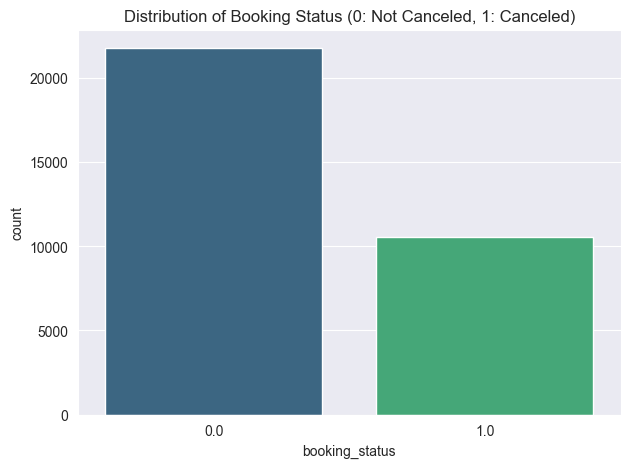

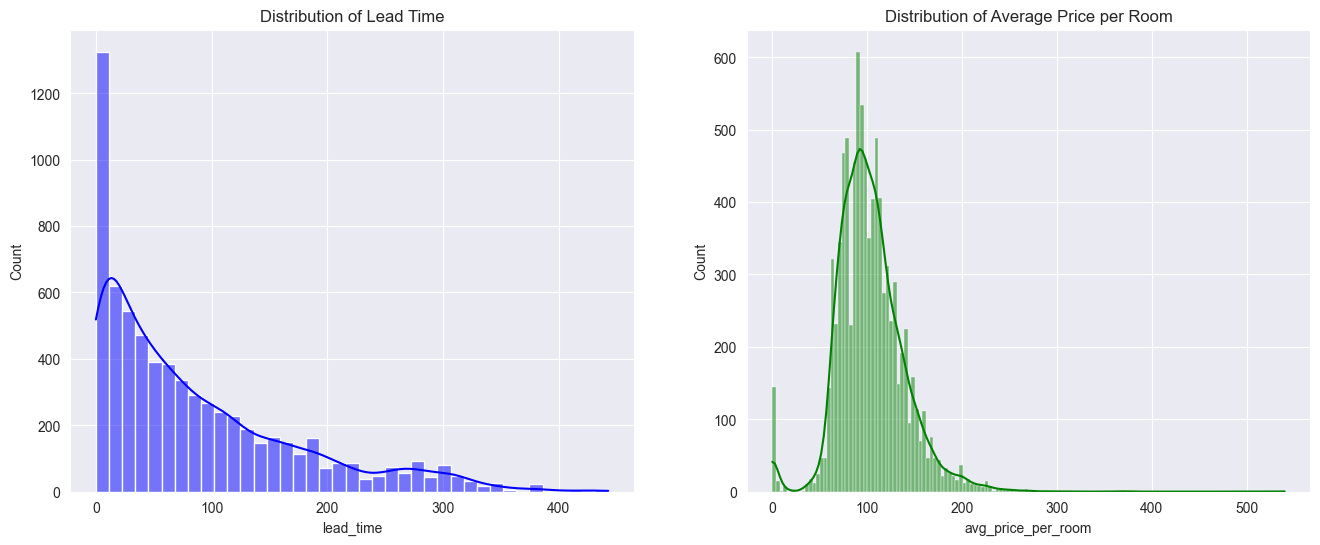

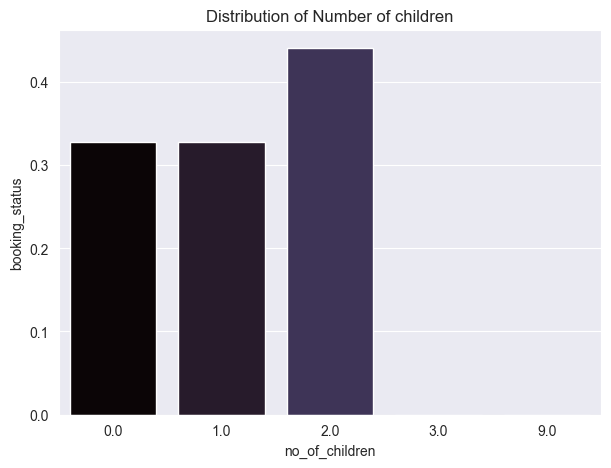

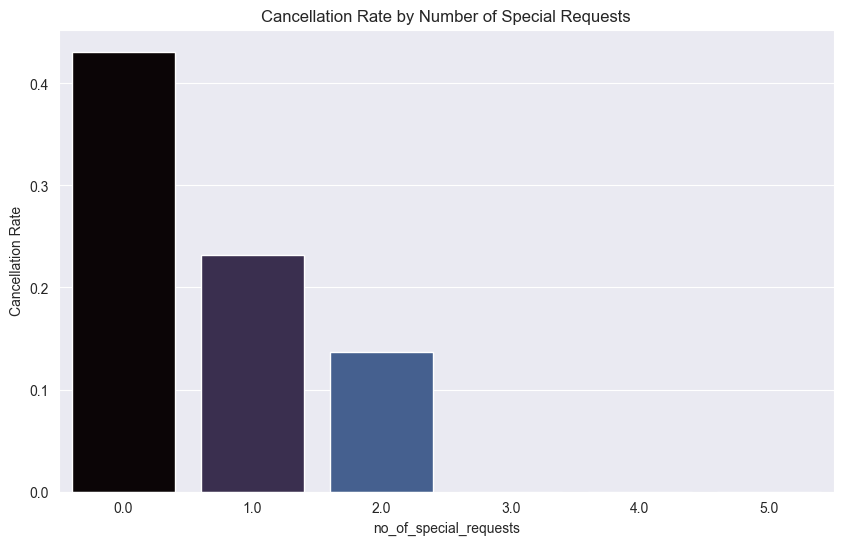

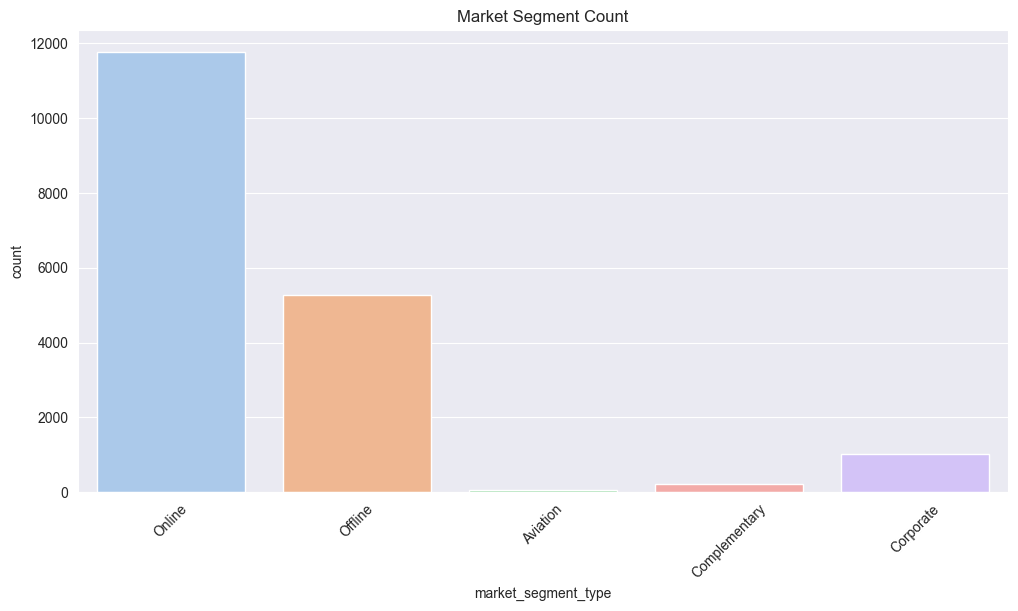

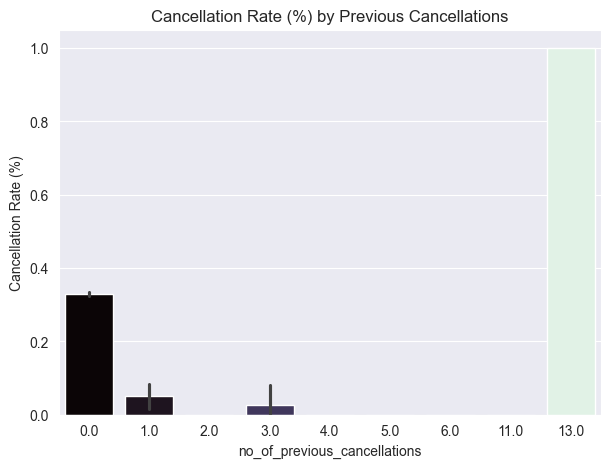

In [7]:
plt.figure(figsize=(7, 5))
# Fix: Assigned 'booking_status' to both x and hue, then set legend=False
sns.countplot(
    data=df_clean,
    x='booking_status',
    hue='booking_status',
    legend=False,
    palette='viridis'
)
plt.title('Distribution of Booking Status (0: Not Canceled, 1: Canceled)')
plt.show()
# B. Distributions of Key Features
# Lead Time and Average Price are usually strong predictors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_clean['lead_time'].dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Lead Time')

sns.histplot(df_clean['avg_price_per_room'].dropna(), kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Average Price per Room')

plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(
    x='no_of_children',
    y='booking_status',
    data=df_clean,
    errorbar=None,
    hue="no_of_children",
    legend=False,
    palette='mako'
)

plt.title('Distribution of Number of children')
plt.show()
# C. Relationships with the Target Variable

# Special Requests vs. Status
# Fix: Replaced 'ci' with 'errorbar' and assigned 'x' to 'hue'
plt.figure(figsize=(10, 6))
sns.barplot(
    x='no_of_special_requests',
    y='booking_status',
    data=df_clean,
    errorbar=None,
    hue='no_of_special_requests',
    legend=False,
    palette='mako'
)
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Number of Special Requests')
plt.show()

# Market Segment vs. Status
# Fix: Assigned 'x' to 'hue' to satisfy the new requirement
plt.figure(figsize=(12, 6))
sns.countplot(
    x='market_segment_type',
    hue='market_segment_type',
    data=df_clean,
    palette='pastel',
    legend=False
)
# Note: If you want to see the breakdown of cancellation WITHIN the segment:
# sns.countplot(x='market_segment_type', hue='booking_status', data=df_clean, palette='pastel')

plt.title('Market Segment Count')
plt.xticks(rotation=45)
plt.show()


## cancellation rate by previous cancellations
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x='no_of_previous_cancellations',
    y='booking_status',
    hue='no_of_previous_cancellations',
    palette='mako',
    legend=False
)

plt.title("Cancellation Rate (%) by Previous Cancellations")
plt.ylabel("Cancellation Rate (%)")
plt.show()


Here we looked at plots depicting the relationship between various variables. In the first graph ("Distribution of Booking Status (0: Not Canceled, 1: Canceled") we can see the number of cancellations.

C:\Users\Richard\AppData\Local\Temp\ipykernel_18368\1304412731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='booking_status', y=col, palette='Set2')
C:\Users\Richard\AppData\Local\Temp\ipykernel_18368\1304412731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='booking_status', y=col, palette='Set2')
C:\Users\Richard\AppData\Local\Temp\ipykernel_18368\1304412731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='booking_status', y=col, palette='Set2')
C:\Users\Richard\AppData\Loc

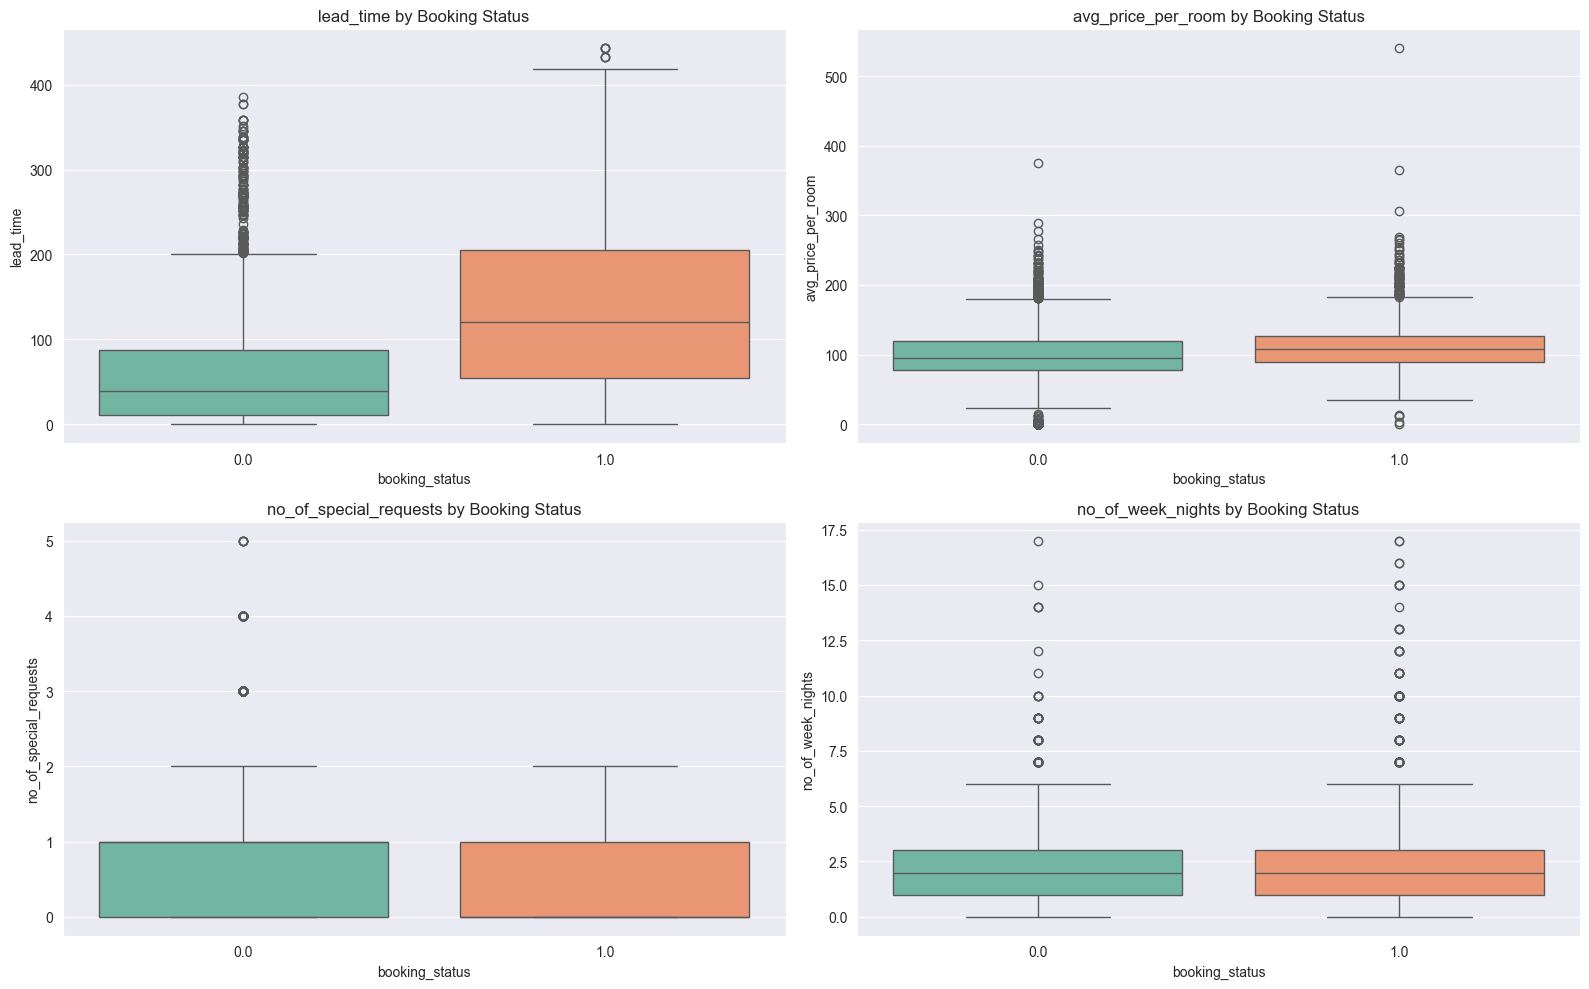

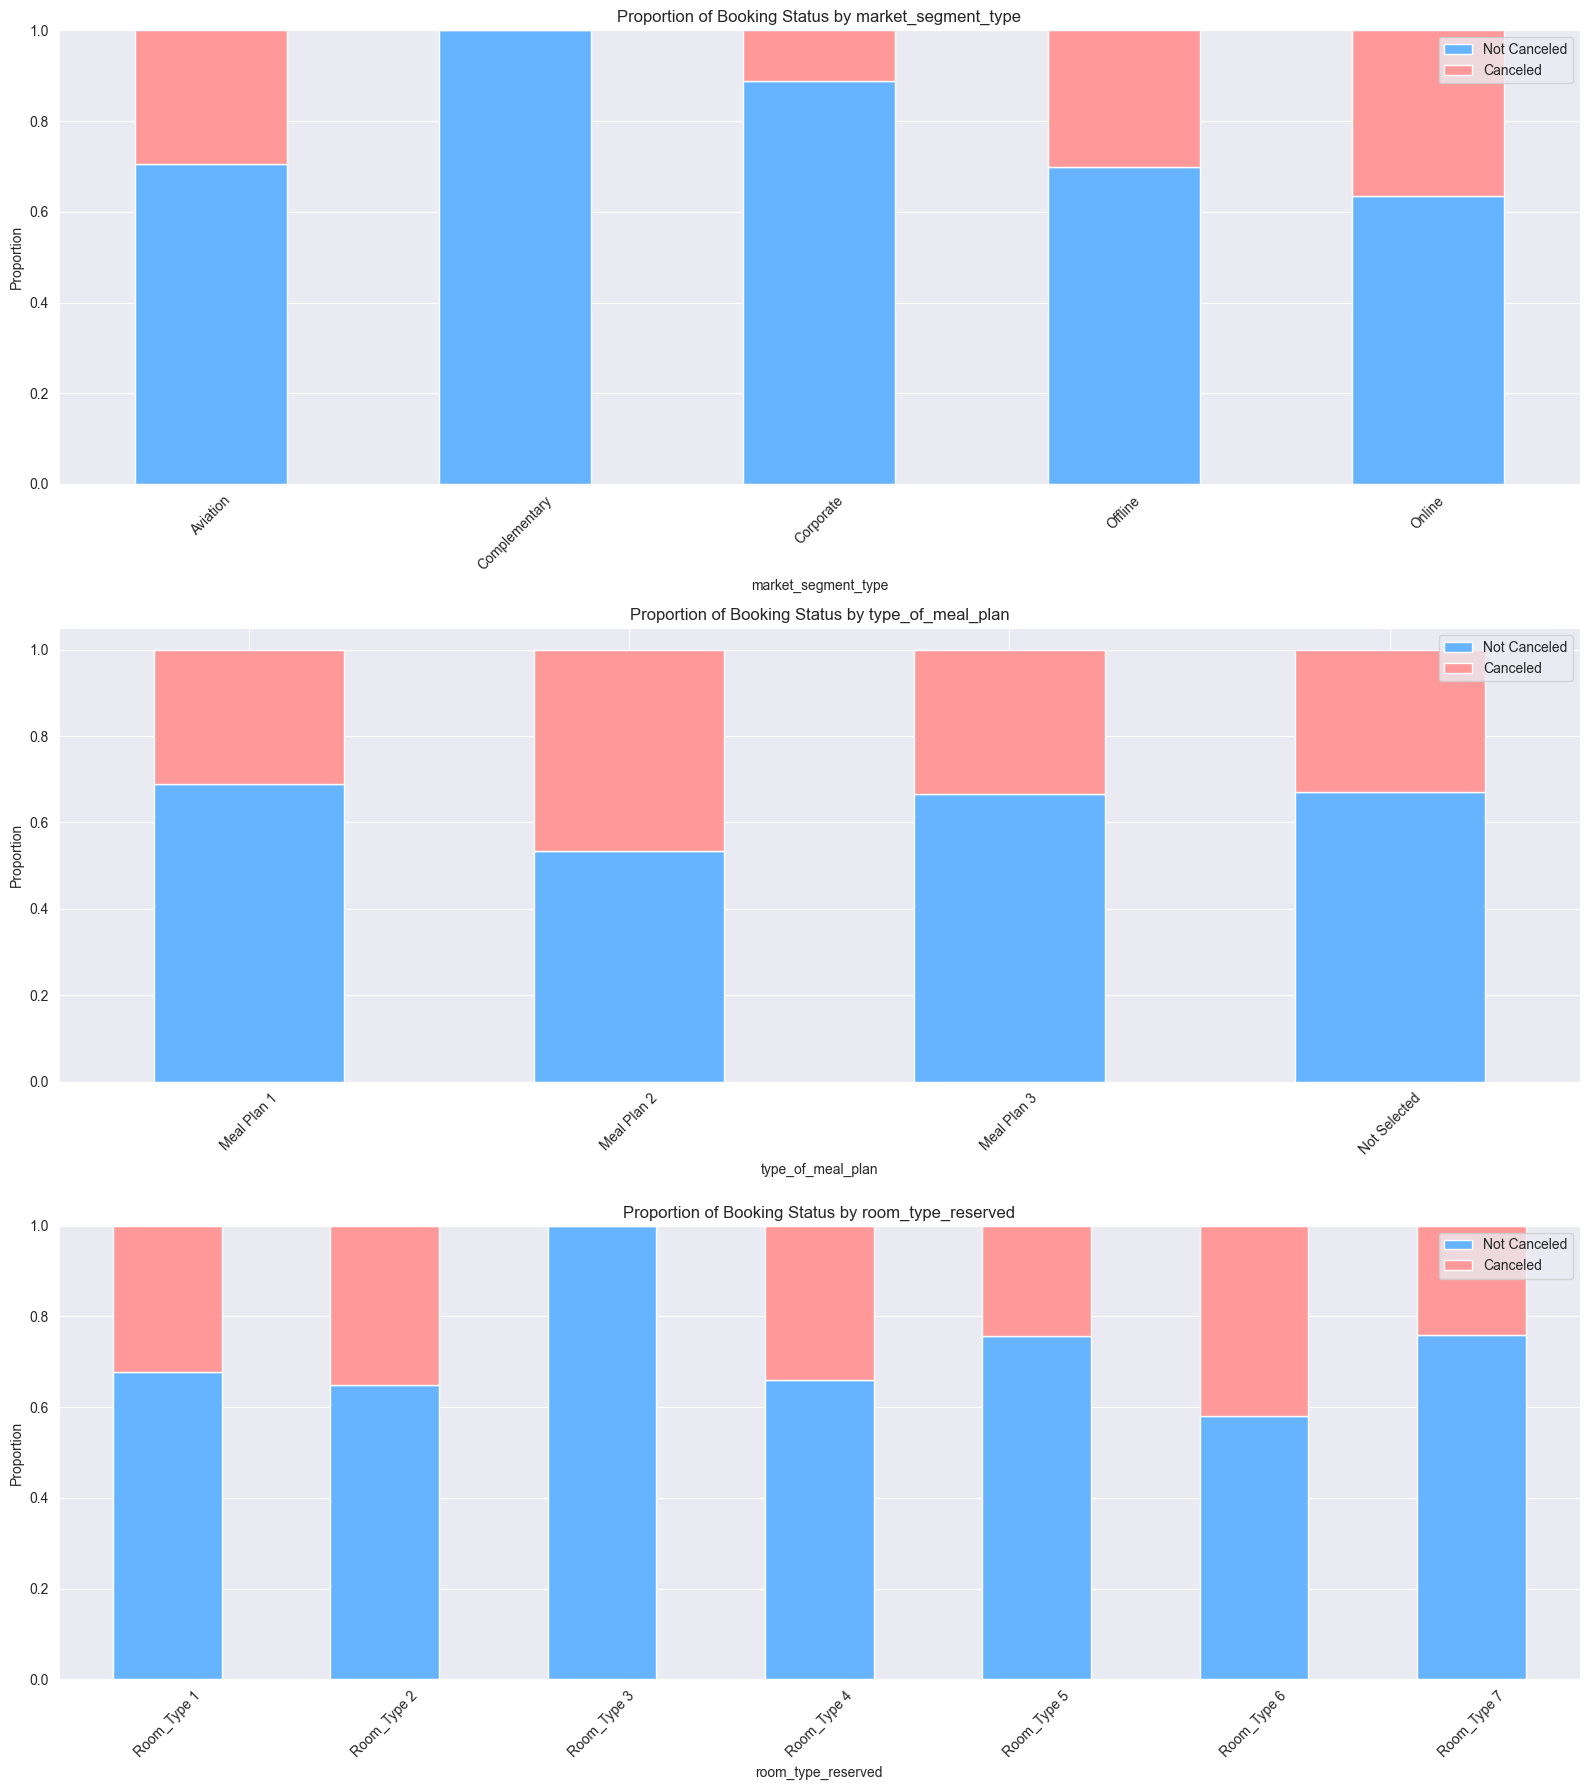

In [8]:
num_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'no_of_week_nights']
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_clean, x='booking_status', y=col, palette='Set2')
    plt.title(f'{col} by Booking Status')
plt.tight_layout()
plt.show()
cat_features = ['market_segment_type', 'type_of_meal_plan', 'room_type_reserved']
plt.figure(figsize=(16, 18))
for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 1, i)
    counts = df_clean.groupby([col, 'booking_status']).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    proportions.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#66b3ff', '#ff9999'])
    plt.title(f'Proportion of Booking Status by {col}')
    plt.ylabel('Proportion')
    plt.legend(['Not Canceled', 'Canceled'], loc='upper right')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TODO

# 2 - Predictor definition

In [14]:
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns)

X = df_imputed.drop(columns=['booking_status'])
y = df_imputed['booking_status']

# Pearson Correlation
correlations = df_imputed.corr()['booking_status'].abs().drop('booking_status')

#Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)

#F-test Importance (Univariate importance)
# This calculates the ANOVA F-value for each feature
f_values, p_values = f_classif(X, y)
f_series = pd.Series(f_values, index=X.columns)

# --- METHOD 4: Random Forest Importance (Multivariate/Embedded) ---
#rf = RandomForestClassifier(n_estimators=100, random_state=42)
#rf.fit(X, y)
#rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

# 2. Combine and Compare Strengths
importance_df = pd.DataFrame({
    'Correlation': correlations,
    'Mutual_Info': mi_series,
    'Univariate_F_Score': f_series
}).sort_values(by='Univariate_F_Score', ascending=False)

print("Comprehensive Predictor Strength Assessment:")
print(importance_df)

Comprehensive Predictor Strength Assessment:
                                      Correlation  Mutual_Info  \
no_of_special_requests                   0.215371     0.028163   
lead_time                                0.192364     0.030582   
arrival_year                             0.161776     0.015293   
no_of_week_nights                        0.081489     0.010071   
no_of_adults                             0.080207     0.009832   
avg_price_per_room                       0.075663     0.023956   
required_car_parking_space               0.065966     0.000000   
market_segment_type                      0.055285     0.012843   
repeated_guest                           0.052760     0.001320   
no_of_previous_bookings_not_canceled     0.046443     0.005954   
no_of_previous_cancellations             0.032914     0.001856   
no_of_weekend_nights                     0.031842     0.002432   
arrival_month                            0.014599     0.016008   
no_of_children                 

In [11]:
## AUC
auc_scores = {}
for col in X.columns:
    y_score = X[col].values
    #  ROC curve
    fpr, tpr, thresholds = metrics.roc_curve(y, y_score)
    #  AUC
    auc_scores[col] = metrics.auc(fpr, tpr)
auc_series = pd.Series(auc_scores).sort_values(ascending=False)

print(auc_series)

lead_time                               0.571624
arrival_year                            0.563759
no_of_week_nights                       0.541476
avg_price_per_room                      0.540163
no_of_adults                            0.538526
market_segment_type                     0.517298
no_of_weekend_nights                    0.511468
type_of_meal_plan                       0.504895
no_of_children                          0.501024
room_type_reserved                      0.500113
arrival_date                            0.498878
repeated_guest                          0.495617
no_of_previous_cancellations            0.493938
no_of_previous_bookings_not_canceled    0.490658
required_car_parking_space              0.490520
arrival_month                           0.478108
no_of_special_requests                  0.388299
dtype: float64


In [12]:
#auc_scores = {}

#for col in X.columns:
#    model = LogisticRegression(max_iter=1000)
#    model.fit(X[[col]], y)
#    preds = model.predict_proba(X[[col]])[:, 1]
#    auc_scores[col] = roc_auc_score(y, preds)

#print(pd.Series(auc_scores).sort_values(ascending=False))

## zhruba rovnaké

We're choosing
no_of_special_requests,
lead_time, arrival_year,
no_of_week_nights,
no_of_adults,
avg_price_per_room,
market_segment_type,
repeated_guest
The reasons being their values rank highgest in our strength predictor assesment.

In [17]:
le.classes_

AttributeError: 'LabelEncoder' object has no attribute 'classes_'

# 3 - Variable encoding

In [18]:
# mean target encoding function
def mean_target_encoding(dt, predictor, target, alpha = 0.01):
    total_cnt = len(dt)
    total_dr = np.mean(dt[target])
    dt_grp = dt.groupby(predictor).agg(
        categ_dr = (target, 'mean'),
        categ_cnt = (target, len)
    )

    dt_grp['categ_freq'] = dt_grp['categ_cnt'] / total_cnt
    dt_grp['categ_encoding'] = (dt_grp['categ_freq'] * dt_grp['categ_dr'] + alpha * total_dr) / (dt_grp['categ_freq'] + alpha)

    return dt_grp[['categ_encoding']].to_dict()['categ_encoding']

selected_features = [
    'no_of_special_requests', 'lead_time', 'arrival_year',
    'no_of_week_nights', 'no_of_adults', 'avg_price_per_room',
    'market_segment_type', 'repeated_guest'
]
target_col = 'booking_status'

# Drop rows where the target variable is missing
df_clean = df.dropna(subset=[target_col]).copy()

# 3. Imputation (Handling Missing Values)
# We use 'median' for numbers to avoid outlier bias and 'most_frequent' for text
num_cols = ['no_of_special_requests', 'lead_time', 'arrival_year',
            'no_of_week_nights', 'no_of_adults', 'avg_price_per_room', 'repeated_guest']
cat_cols = ['market_segment_type']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])
df_clean[cat_cols] = cat_imputer.fit_transform(df_clean[cat_cols])

# 4. Variable Encoding
# Apply Target Encoding to 'market_segment_type'
encoding_map = mean_target_encoding(df_clean, 'market_segment_type', target_col, alpha=0.01)
df_clean['market_segment_encoded'] = df_clean['market_segment_type'].map(encoding_map)

# 5. Numerical Transformations
# Apply Log Transform to 'lead_time' and 'avg_price_per_room' (Skewed variables)
# We use log1p to safely handle zero values: log(1 + x)
df_clean['lead_time_log'] = np.log1p(df_clean['lead_time'])
df_clean['avg_price_per_room_log'] = np.log1p(df_clean['avg_price_per_room'])

# 6. Final Feature Selection
# Retain only the transformed and relevant columns
X = df_clean[[
    'no_of_special_requests', 'lead_time_log', 'arrival_year',
    'no_of_week_nights', 'no_of_adults', 'avg_price_per_room_log',
    'market_segment_encoded', 'repeated_guest'
]]
y = df_clean[target_col]

# 7. Standardization (Scaling)
# This centers all data at 0 with a standard deviation of 1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 8. Combine into a final cleaned training set
df_final = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# Display the result
print("Final Preprocessed Features:")
print(df_final.head())

Final Preprocessed Features:
   no_of_special_requests  lead_time_log  arrival_year  no_of_week_nights  \
0                0.704246       0.104728      0.441393          -0.124444   
1               -0.652287       0.104728      0.441393          -0.124444   
2                0.704246       0.104728      0.441393          -0.124444   
3                2.060779       0.861542      0.441393           0.695239   
4               -0.652287       0.104728      0.441393          -0.944126   

   no_of_adults  avg_price_per_room_log  market_segment_encoded  \
0       0.27717                0.056042                0.370481   
1       0.27717                0.056042                0.370481   
2      -1.79104                0.056042                0.370481   
3       2.34538                0.056042                0.370481   
4      -1.79104                1.217210                0.370481   

   repeated_guest  booking_status  
0       -0.078342             0.0  
1       -0.078342             0.0

Encode categorial variables using mean target encoding function(cviko)

# 4 - Hyperparameter selection

In [17]:
params_grid = [
    {
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    }
]

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params_grid,
    cv=3,
    scoring='f1'
)
grid_search.fit(X, y)
print(f"Best Grid Search Params: {grid_search.best_params_}")

KeyboardInterrupt: 

In [ ]:
params_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_leaf': randint(1, 5)
}

halving_search = HalvingRandomSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=params_dist,
    n_candidates=20,    # <--- Add this! (e.g., try 20 different model settings)
    factor=2,
    resource='n_samples',
    min_resources='exhaust', # Now 'exhaust' will work because it knows n_candidates
    cv=3,
    scoring='f1',
    random_state=42
)
halving_search.fit(X, y)
print(halving_search.best_params_)

In [ ]:
## part 5
# Cross validation

# 5: Model score validation (cross validation)

In [19]:
# preparation of the data
df_test = pd.read_csv("2025_DS2_HW1_data_test.csv")
selected_cols = ['no_of_special_requests', 'lead_time', 'arrival_year',
    'no_of_week_nights', 'no_of_adults', 'avg_price_per_room',
    'market_segment_type', 'repeated_guest']
X_train_raw = df_clean[selected_cols].copy()
y_train = df_clean["booking_status"]

X_test_raw = df_test[selected_cols].copy()

We selected the desired columns choosen above.

In [20]:
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()
encoders = {}

cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # handle unseen categories in test safely
    X_test[col] = X_test[col].astype(str)
    X_test[col] = X_test[col].map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )

    encoders[col] = le

C:\Users\Richard\AppData\Local\Temp\ipykernel_18368\325978782.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


We encoded our categorical variable (only market_segment_type) into str.

In [21]:
# fill in missing values
# 1. categoricals first
cat_cols = X_train.select_dtypes(include=['object']).columns # should only be market_segment_type

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_test[cat_cols] = enc.transform(X_test[cat_cols])

# 2. now everything is numeric → imputer
imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns)

We filled in the missing values with median.

In [22]:
X_train_final = X_train_imputed
y_train_final = y_train

X_test_final = X_test_imputed

We finally have our training and testing data in a desired form.

In [23]:
# cross validation
X = X_train_final.values
y = y_train_final.values
X_test = X_test_final.values

## stratification: 5 folds, randomizing before splitting
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

# out of fold predictions ...??
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))


params = {
    'eta': 0.1,
    'max_depth': 3,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'booster': 'gbtree',
    'tree_method': 'exact',
    'seed': 12
}

We chose 5 splits in cross validation of the model, dept of the tree as 3.

In [24]:
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"Fold {fold + 1}")

    X_tr, X_val = X[train_idx], X[val_idx] # ... training data for this fold
    y_tr, y_val = y[train_idx], y[val_idx] # ... testing data for this fold

    dtrain = xgb.DMatrix(X_tr, y_tr) # ... learning model
    dval   = xgb.DMatrix(X_val, y_val) # validation model, checking performance during training
    dtest  = xgb.DMatrix(X_test) # ... used for final prediction

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=15,
        verbose_eval=False
    )

    # ---- validation predictions (OOF)
    val_pred = model.predict(dval, iteration_range=(0, model.best_iteration)) # predict only on validation data, uses best number of trees
    oof[val_idx] = val_pred # ...Each row in training data gets a prediction from a model that never saw it during training.

    # ---- test predictions (average)
    test_preds += model.predict(dtest,iteration_range=(0, model.best_iteration)) / skf.n_splits
    # ---- train predictions:
    train_pred = model.predict(dtrain, iteration_range=(0, model.best_iteration))
    # --- best iteration
    best_iter = model.best_iteration

    # ---- gini score
    gini_train = 2 * roc_auc_score(y_tr, train_pred) - 1
    gini_val   = 2 * roc_auc_score(y_val, val_pred) - 1

    cv_scores += [(gini_train, gini_val, best_iter)]

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


We took our desired version of "2025_DS2_HW1_data_train.csv" and divided that into training and validating data. We traind our model on this and then predicted the booking status on "2025_DS2_HW1_data_test.csv".

In [25]:
cv_scores

[(0.5172718140195647, 0.5111645632614934, 140),
 (0.5327242494994893, 0.5086404770531665, 219),
 (0.5269408111161449, 0.49833928485679224, 167),
 (0.5235065409730986, 0.5087722036206799, 154),
 (0.5361220072313193, 0.5152333235499178, 269)]

The gini score of our predictions is ~0.5, meaning the AUC is ~0.75, which is fairly good.

In [26]:
print("Mean CV AUC:", (cv_scores))

df_test['prediction'] = test_preds
df_test['prediction'] = (test_preds >= 0.5).astype(int)
df_test["prediction"]


Mean CV AUC: [(0.5172718140195647, 0.5111645632614934, 140), (0.5327242494994893, 0.5086404770531665, 219), (0.5269408111161449, 0.49833928485679224, 167), (0.5235065409730986, 0.5087722036206799, 154), (0.5361220072313193, 0.5152333235499178, 269)]


0       0
1       0
2       0
3       1
4       0
       ..
3588    0
3589    1
3590    1
3591    0
3592    0
Name: prediction, Length: 3593, dtype: int64

# 6 - SHAP value interpretation

1) Randoming my features - permutation (denote z)
2) Select random sample from original dataset that serves as a reference (denote x)
3) Create 2 hybrid samples - lets assume we want to know the contribution of feature j. In our ordered list, we look at all the features that come before feature j. Then, we look at the features from the permuted list and take the features that come after feature j.
4) We compute the difference between these two hybrid samples to isolate the impact of our target feature

In [27]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import shap
shap.initjs()

C:\Users\Richard\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
## we will be working with df_imputed (clean, nan values replaced with median)
#df_imputed.head()
X = df_imputed.drop(columns=['booking_status'])
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2.0,0.0,1.0,2.0,1.0,0.0,5.0,59.0,2018.0,9.0,16.0,4.0,0.0,0.0,0.0,100.0,1.0
1,2.0,0.0,1.0,2.0,0.0,0.0,7.0,59.0,2018.0,12.0,16.0,4.0,0.0,0.0,0.0,100.0,0.0
2,1.0,0.0,1.0,2.0,4.0,0.0,0.0,59.0,2018.0,11.0,16.0,5.0,0.0,0.0,0.0,100.0,1.0
3,3.0,0.0,1.0,3.0,4.0,0.0,7.0,100.0,2018.0,5.0,16.0,4.0,0.0,0.0,0.0,100.0,2.0
4,1.0,0.0,1.0,1.0,0.0,0.0,7.0,59.0,2018.0,11.0,16.0,5.0,0.0,0.0,0.0,150.0,0.0


<Axes: >

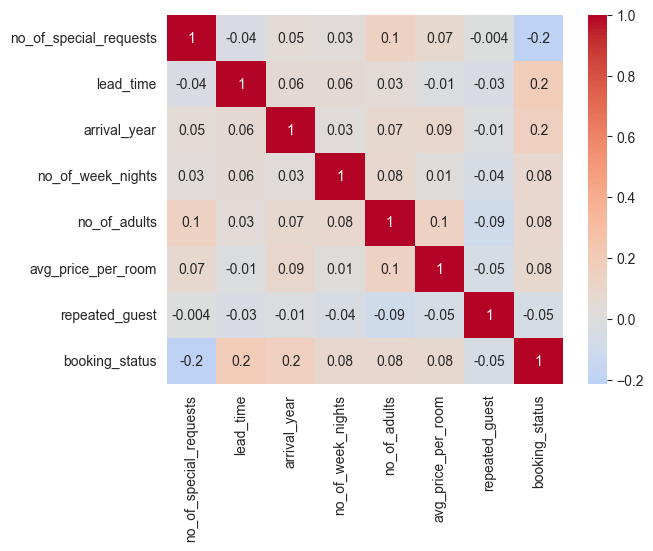

In [31]:
int_features = ['no_of_special_requests', 'lead_time', 'arrival_year',
    'no_of_week_nights', 'no_of_adults', 'avg_price_per_room','repeated_guest',"booking_status"]
corr_matrix = pd.DataFrame(df_imputed[int_features],columns = int_features).corr()

sns.heatmap(corr_matrix,
            cmap = "coolwarm",
            center = 0,
            annot = True,
            fmt='.1g')

## 1.1 - SHAP values

In [31]:
print(shap_values.feature_names)

NameError: name 'shap_values' is not defined

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X) # recall: X = df_imputed.drop(columns=['booking_status']), y = df_imputed['booking_status']
np.shape(shap_values.values)

In [ ]:
print(shap_values.feature_names)

There are 8 SHAP values for each of the 32 295 observations.

## Waterfall plot

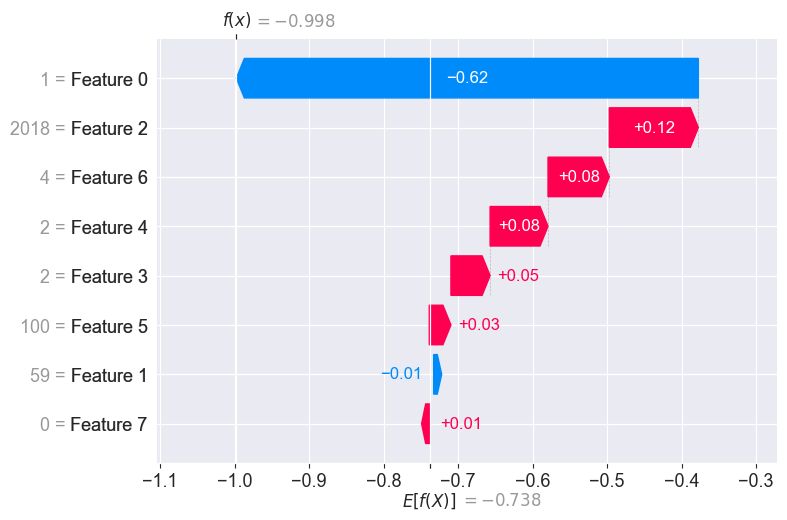

In [40]:
# waterfall plot for first observation:
shap.plots.waterfall(shap_values[0]) # !! prečo sú tam názvy Feature 0,1,...?? Also problém v tom že to je binárna target value :((

E[f(X)] = -0,738 is the average predicted log odds for the target variable.
f(X) = ln(P/(1-P)) = -0.998 ... predicted log odds
The shap value by each feature represents the addition in the log odds.